In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3581967.2457502945


In [4]:
model_name = 'single_conv_layer'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1263/1263 [00:00<00:00, 130606.66it/s]
Computing layer execution times: 3000it [00:00, 969557.10it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for single_conv_layer: 1263
Number of TensorRT layers in single_conv_layer: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 1.317845 seconds


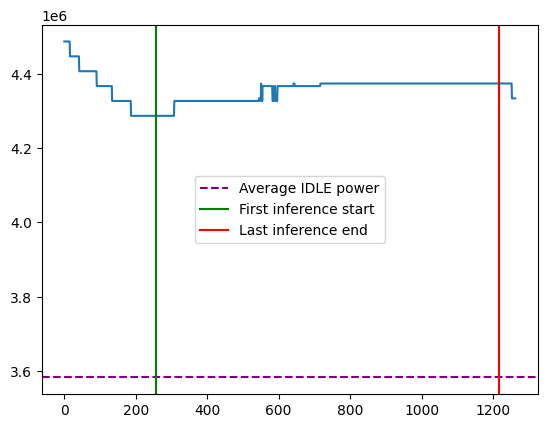

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 952385.10it/s]


In [13]:
metrics_df.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,4.840000e+02,484.000000,3000.000000
mean,1500.500000,4.356820e+06,774852.985655,0.222687
std,866.169729,2.532084e+04,25320.836584,0.070758
min,1.000000,4.286848e+06,704880.754250,0.074240
25%,750.750000,4.326912e+06,744944.754250,0.213632
50%,1500.500000,4.373952e+06,791984.754250,0.216976
75%,2250.250000,4.373952e+06,791984.754250,0.226016
max,3000.000000,4.373952e+06,791984.754250,2.781088


In [14]:
metrics_df.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     484
layer_power_excluding_idle_power_micro_watt     484
layer_run_time                                 3000
dtype: int64

<Axes: >

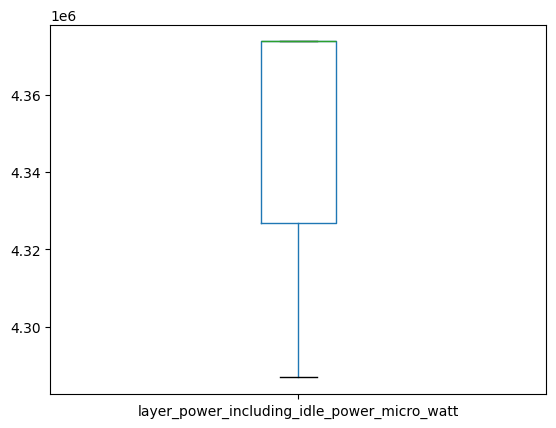

In [18]:
metrics_df.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)